# 3_pitchfork_test

Testing results from single pitchfork

In [1]:
#### misc
import pandas as pd
import numpy as np
import os
from pathlib import Path
import pickle
import time
from itertools import product
from scipy import constants
from scipy import stats
import random
import astropy.constants
from numpy.random import default_rng

#### graphical
import matplotlib.pyplot as plt

#### ML
import sklearn
from sklearn.decomposition import PCA
import tensorflow as tf
import keras
from keras import layers

#### custom
from InversePCA import InversePCA
from WMSE import WMSE, WMSE_metric

##### poke gpu
os.environ["CUDA_VISIBLE_DEVICES"]="0"

physical_devices = tf.config.list_physical_devices("GPU") 

gpu0usage = tf.config.experimental.get_memory_info("GPU:0")["current"]

print("Current GPU usage:\n"
     + " - GPU0: " + str(gpu0usage) + "B\n")

2024-03-12 13:39:11.900319: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-03-12 13:39:11.900350: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-03-12 13:39:11.901213: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-03-12 13:39:11.905947: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-03-12 13:39:12.475070: W tensorflow/compiler/tf2

Current GPU usage:
 - GPU0: 0B



2024-03-12 13:39:13.000999: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 18044 MB memory:  -> device: 0, name: NVIDIA RTX A4500, pci bus id: 0000:41:00.0, compute capability: 8.6


## 1) load in grid
keep same routine as during training

In [5]:
df_full = pd.read_hdf('/home/oxs235/datastorage/repos_data/ojscutt/pitchfork/data/bob.h5', key='df')

#### define inputs
inputs = ['log_initial_mass_std', 'log_initial_Zinit_std', 'log_initial_Yinit_std', 'log_initial_MLT_std', 'log_star_age_std']

#### define outputs
classical_outputs = ['log_radius_std', 'log_luminosity_std', 'log_surface_Z_std']
astero_outputs = [f'log_nu_0_{i+1}_std' for i in range(15,25)]

outputs = classical_outputs+astero_outputs

#### train/test split
seed = 42

df_train = df_full.sample(frac=0.95, random_state=seed)
df_test = df_full.drop(df_train.index)

df_train_inputs, df_val_inputs, df_train_outputs, df_val_outputs = sklearn.model_selection.train_test_split(df_train[inputs],df_train[outputs], test_size = 0.005, random_state=seed)

print("Training set: ", len(df_train_inputs))
print("Testing set: ", len(df_test))
print("Validation set: ", len(df_val_inputs))

#### can't have too many describes
df_full.describe()

Training set:  2314615
Testing set:  122434
Validation set:  11632


,initial_mass,initial_Zinit,initial_Yinit,initial_MLT,star_age,radius,luminosity,effective_T,surface_Z,nu_0_4,...,log_nu_0_31_std,log_nu_0_32_std,log_nu_0_33_std,log_nu_0_34_std,log_nu_0_35_std,log_nu_0_36_std,log_nu_0_37_std,log_nu_0_38_std,log_nu_0_39_std,log_nu_0_40_std
count,2.448681e+06,2.448681e+06,2.448681e+06,2.448681e+06,2.448681e+06,2.448681e+06,2.448681e+06,2.448681e+06,2.448681e+06,2.448681e+06,...,2.448681e+06,2.448681e+06,2.448681e+06,2.448681e+06,2.448681e+06,2.448681e+06,2.448681e+06,2.448681e+06,2.448681e+06,2.448681e+06
mean,1.021885e+00,1.440698e-02,2.814693e-01,2.117984e+00,5.000177e+00,1.312728e+00,2.116482e+00,5.870890e+03,1.343075e-02,5.459277e+02,...,5.100371e-15,3.629539e-15,2.700240e-15,1.435547e-15,-4.423639e-15,8.003407e-15,-8.417543e-15,1.289578e-15,-3.185318e-15,3.670395e-15
std,1.175610e-01,9.677123e-03,2.805593e-02,2.879175e-01,3.405371e+00,4.813547e-01,1.572419e+00,5.674285e+02,9.561540e-03,2.021373e+02,...,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,8.000000e-01,3.869061e-03,2.400000e-01,1.700000e+00,2.966411e-02,6.990236e-01,1.321735e-01,4.099787e+03,1.354099e-03,1.545097e+02,...,-2.605045e+00,-2.599363e+00,-2.594960e+00,-2.591708e+00,-2.589646e+00,-2.588901e+00,-2.589287e+00,-2.590747e+00,-2.593002e+00,-2.595848e+00
25%,9.200000e-01,6.471429e-03,2.600000e-01,1.900000e+00,2.309880e+00,9.719693e-01,9.371542e-01,5.495672e+03,5.437183e-03,3.986516e+02,...,-5.612334e-01,-5.643108e-01,-5.676179e-01,-5.705508e-01,-5.723483e-01,-5.730070e-01,-5.725672e-01,-5.713737e-01,-5.700038e-01,-5.685747e-01
50%,1.040000e+00,1.077191e-02,2.800000e-01,2.100000e+00,4.275231e+00,1.160016e+00,1.698469e+00,5.863863e+03,1.048844e-02,5.591040e+02,...,2.414913e-01,2.417789e-01,2.415099e-01,2.405877e-01,2.389688e-01,2.369176e-01,2.348740e-01,2.333131e-01,2.326247e-01,2.327753e-01
75%,1.120000e+00,2.007835e-02,3.000000e-01,2.300000e+00,7.159688e+00,1.498369e+00,2.883064e+00,6.223793e+03,1.928386e-02,6.947397e+02,...,7.562359e-01,7.569644e-01,7.578097e-01,7.587334e-01,7.595544e-01,7.599729e-01,7.598420e-01,7.591873e-01,7.580180e-01,7.566985e-01
max,1.200000e+00,3.897971e-02,3.200000e-01,2.500000e+00,1.399997e+01,2.873431e+00,1.163902e+01,7.998610e+03,3.907980e-02,1.021990e+03,...,1.616724e+00,1.617024e+00,1.618137e+00,1.620054e+00,1.622624e+00,1.625764e+00,1.629202e+00,1.632519e+00,1.633559e+00,1.635647e+00


In [6]:
"""
pca
"""
#### define pca global vars
n_components = 5
seed = 42

#### define and fit pca
pca = PCA(n_components=n_components, random_state=seed)
pca.fit(df_full[astero_outputs])

#### print variance with chosen n_comps
print("Explained variance ratio with n_comps = " + str(n_components) + " is " + str(sum(pca.explained_variance_ratio_)))

Explained variance ratio with n_comps = 5 is 0.999999986464659


In [9]:
"""
DEFINE WEIGHTS FOR WMSE
"""
log_weights = (1/np.log(10)) * np.array(([0.01, 0.02, 0.0001]+[0.1 for i in range(len(astero_outputs))]) / df_full[["radius", "luminosity", "surface_Z"] + [f'nu_0_{i+1}' for i in range(15,25)]].mean())

log_weights = log_weights / df_full[["log_radius", "log_luminosity", "log_surface_Z"] + [f'log_nu_0_{i+1}' for i in range(15,25)]].std()


weights = log_weights.values.tolist()

print(weights)

[0.02324560601067967, 0.012220076304794422, 0.009762892656483512, 0.00011530706805035573, 0.000109209187475727, 0.00010373957827574545, 9.877493746324607e-05, 9.424043658607474e-05, 9.008674371702482e-05, 8.626668769588676e-05, 8.273438289926203e-05, 7.944721575439512e-05, 7.636537366843286e-05]


In [27]:
"""
Loading into json for inference test
"""
import json

emulator_dict = {
    "architecture": "stem_2_256_ctine_2_64_atine_12_128_WMSE_32768batch_exp2e4_100kepochs_swish_001lr_0001exp_bob",
    "data_scaling":{
        "inp_mean":{
            inp : df_full[inp].mean().tolist() for inp in ['log_initial_mass', 'log_initial_Zinit', 'log_initial_Yinit', 'log_initial_MLT', 'log_star_age']
        },
        "classical_out_mean":{
            out : df_full[out].mean().tolist() for out in ['log_radius', 'log_luminosity', 'log_surface_Z']
        },
        "astero_out_mean":{
            out : df_full[out].mean().tolist() for out in [f'log_nu_0_{i+1}' for i in range(15,25)]
        },
        "inp_std":{
            inp : df_full[inp].std().tolist() for inp in ['log_initial_mass', 'log_initial_Zinit', 'log_initial_Yinit', 'log_initial_MLT', 'log_star_age']
        },
        "classical_out_std":{
            out : df_full[out].std().tolist() for out in ['log_radius', 'log_luminosity', 'log_surface_Z']
        },
        "astero_out_std":{
            out : df_full[out].std().tolist() for out in [f'log_nu_0_{i+1}' for i in range(15,25)]
        },
    },
    "custom_objects":{
        "inverse_pca":{
            "pca_comps":pca.components_.tolist(),
            "pca_mean":pca.mean_.tolist(),
        },
        "WMSE":{
            "weights":weights
        },
    },
    "parameter_ranges":{
        inp:{
            "min": 10**(df_full[inp].min()),
            "max": 10**(df_full[inp].max())
        } for inp in ['log_initial_mass', 'log_initial_Zinit', 'log_initial_Yinit', 'log_initial_MLT', 'log_star_age']
    },
}
with open('stem_2_256_ctine_2_64_atine_12_128_WMSE_32768batch_exp2e4_100kepochs_swish_001lr_0001exp_bob.json', 'w') as fp:
    json.dump(emulator_dict, fp)

In [16]:
def calc_Teff(luminosity, radius):
    return np.array(((luminosity.values*astropy.constants.L_sun) / (4*np.pi*constants.sigma*((radius.values*astropy.constants.R_sun)**2)))**0.25)

def rescale_preds(preds, df, column):
    if 'star_feh' in column:
        return (preds[column+"_std"]*df[column].std())+df[column].mean()
    else:
        return 10**((preds["log_"+column+"_std"]*df["log_"+column].std())+df["log_"+column].mean())

## Testing results from pitchfork


In [28]:
"""
load in angry mob
"""
pca_comps = pca.components_
pca_mean = pca.mean_

custom_objects = {"InversePCA": InversePCA(pca_comps, pca_mean),"WMSE": WMSE(weights)}
with open('custom_objects.json', 'w') as fp:
    json.dump(custom_objects, fp)

pitchfork_name = "stem_2_256_ctine_2_64_atine_12_128_WMSE_32768batch_exp2e4_100kepochs_swish_001lr_0001exp_40nu"
pitchfork = tf.keras.models.load_model("/home/oxs235/datastorage/repos_data/ojscutt/pitchfork/models/barbie/" + pitchfork_name + ".h5", custom_objects=custom_objects)


TypeError: Object of type InversePCA is not JSON serializable

In [18]:

inputs = ['log_initial_mass_std', 'log_initial_Zinit_std', 'log_initial_Yinit_std', 'log_initial_MLT_std', 'log_star_age_std']

pred_outputs = ['log_radius_std', 'log_luminosity_std', 'log_surface_Z_std'] + [f'log_nu_0_{i+1}_std' for i in range(5,40)]

outputs = ['radius', 'luminosity', 'surface_Z'] + [f'nu_0_{i+1}' for i in range(5,40)]

preds = pitchfork(np.array(df_test[inputs]))

preds_df = pd.DataFrame(np.concatenate((np.array(preds[0]),np.array(preds[1])), axis=1), columns=pred_outputs)


for output in outputs:
    preds_df[output] = rescale_preds(preds_df, df_full, output)

preds_df['effective_T'] = calc_Teff(preds_df["luminosity"],preds_df["radius"])

pitchfork_errors_df=pd.DataFrame(np.array(df_test[outputs+['effective_T']]) - np.array(preds_df[outputs+['effective_T']]), columns=[outputs+['effective_T']])

In [19]:
pitchfork_errors_df

,radius,luminosity,surface_Z,nu_0_6,nu_0_7,nu_0_8,nu_0_9,nu_0_10,nu_0_11,nu_0_12,...,nu_0_32,nu_0_33,nu_0_34,nu_0_35,nu_0_36,nu_0_37,nu_0_38,nu_0_39,nu_0_40,effective_T
0,0.000206,-0.000428,0.000008,-1.555194,-1.870138,-0.425765,-0.356449,0.531924,0.615490,-0.019145,...,0.635306,0.409561,-0.339432,-0.868585,-0.780294,-0.268331,-3.717745,-0.806890,1.771427,1.538015
1,0.000029,-0.000312,0.000006,-1.761322,-2.022656,-0.556301,-0.447670,0.475232,0.582082,-0.099895,...,0.014678,-0.020357,-0.381097,-0.236127,0.228174,-0.307785,-2.204202,0.136722,1.583897,2.616482
2,0.000007,-0.000283,0.000005,-1.738362,-2.025857,-0.589757,-0.513017,0.378569,0.469246,-0.222985,...,-0.094780,-0.110889,-0.432035,-0.223160,0.251676,-0.700668,-2.142253,0.091297,1.379170,2.798586
3,-0.000048,-0.000184,0.000004,-1.565948,-1.906760,-0.540964,-0.549126,0.220070,0.234011,-0.507604,...,-0.271843,-0.273967,-0.514808,-0.192690,0.231651,-4.158521,-2.154225,-0.283378,0.437598,3.333399
4,-0.000067,-0.000145,0.000004,-1.456491,-1.793251,-0.431747,-0.459371,0.268990,0.250257,-0.516276,...,-0.218042,-0.218402,-0.451704,-0.107642,0.274486,-4.049299,-2.106480,-0.389646,0.113893,3.530423
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122429,-0.000175,0.007867,0.000011,-0.020510,-0.214374,-0.494085,0.204344,1.568940,1.447166,0.015827,...,2.680047,0.599722,-1.585759,-2.259101,-1.501509,-0.220559,1.041281,1.731099,1.762835,7.948954
122430,-0.003812,-0.017782,0.000010,1.016552,0.435432,0.529584,0.944702,1.836113,1.956494,0.301756,...,0.837482,-0.956526,-1.670567,-1.120062,-0.218542,0.487735,0.931311,0.951655,0.763174,5.633461
122431,-0.000747,-0.027547,0.000001,0.482573,0.226397,0.288095,1.085429,2.094027,1.361163,-0.615442,...,0.129897,-1.349690,-1.340667,-0.486027,0.400594,1.029326,1.206589,0.933975,0.550952,-3.381206
122432,0.002222,0.009309,0.000008,-0.396817,0.159961,1.976117,2.459261,1.066051,-0.923476,-0.768812,...,-1.162097,0.085394,1.012691,1.491222,1.393564,0.933622,0.241163,-0.359503,-0.729064,3.534376


In [24]:
def output_plot(output, target_unc, axis):
    errors = pitchfork_errors_df[output]
    errors_mad = stats.median_abs_deviation(errors)
    errors_med = np.median(errors)
    
    axis.hist(errors, bins=1000)
    axis.axvline(target_unc, linestyle='dashed', color='black')
    axis.axvline(-target_unc, linestyle='dashed', color='black')
    axis.axvline(0, color='black')
    axis.axvline(errors_med + errors_mad, color='orange')
    axis.axvline(errors_med -errors_mad, color='orange')
    axis.set_xlim(-5*errors_mad, 5*errors_mad)
    axis.set_title(output)
    axis.set_yticks([])

def pitchfork_eval(pitchfork, df_test):
    inputs = ['log_initial_mass_std', 'log_initial_Zinit_std', 'log_initial_Yinit_std', 'log_initial_MLT_std', 'log_star_age_std']

    pred_outputs = ['log_radius_std', 'log_luminosity_std', 'log_surface_Z_std'] + [f'log_nu_0_{i+1}_std' for i in range(5,40)]
    
    outputs = ['radius', 'luminosity', 'surface_Z'] + [f'nu_0_{i+1}' for i in range(5,40)]
    
    preds = pitchfork(np.array(df_test[inputs]))
    
    preds_df = pd.DataFrame(np.concatenate((np.array(preds[0]),np.array(preds[1])), axis=1), columns=pred_outputs)
    
    for output in outputs:
        preds_df[output] = rescale_preds(preds_df, df_full, output)
    
    preds_df['effective_T'] = calc_Teff(preds_df["luminosity"],preds_df["radius"])
    
    pitchfork_errors_df=pd.DataFrame(np.array(df_test[outputs+['effective_T']]) - np.array(preds_df[outputs+['effective_T']]), columns=[outputs+['effective_T']])

    fig, ((ax1, ax2, ax3, ax4), (ax5, ax6, ax7, ax8)) = plt.subplots(2, 4, figsize=(20,10))

    output_plot('radius', 0.01, ax1)

    output_plot('luminosity', 0.02, ax2)
    
    output_plot('effective_T', 5, ax3)

    output_plot('surface_Z', 0.0001, ax4)

    output_plot('nu_0_15', 0.2, ax5)

    output_plot('nu_0_18', 0.2, ax6)

    output_plot('nu_0_21', 0.2, ax7)

    output_plot('nu_0_24', 0.2, ax8)

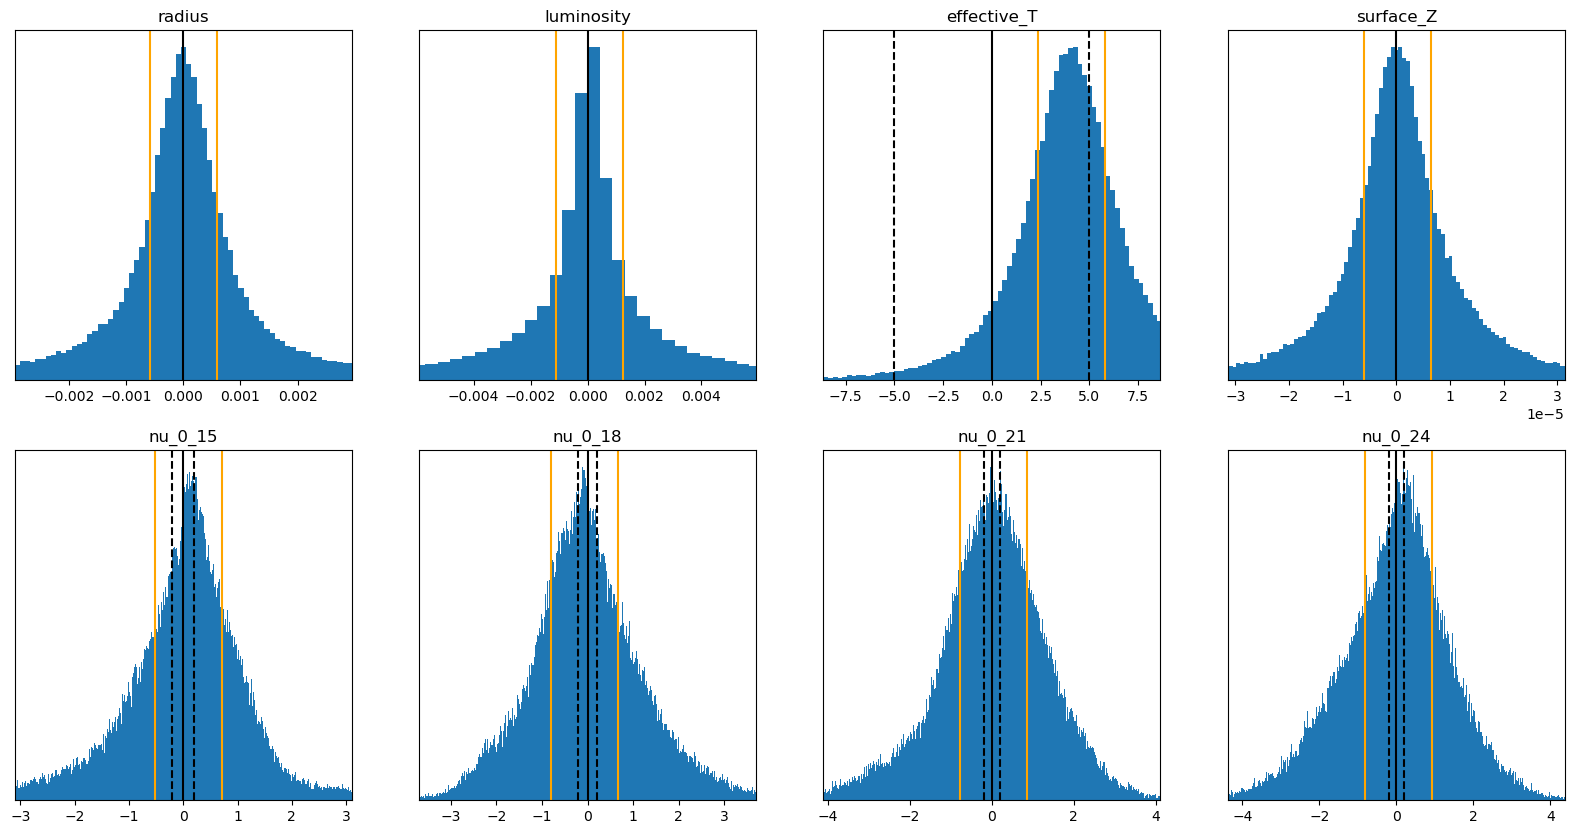

In [25]:
pitchfork_eval(pitchfork, df_test)

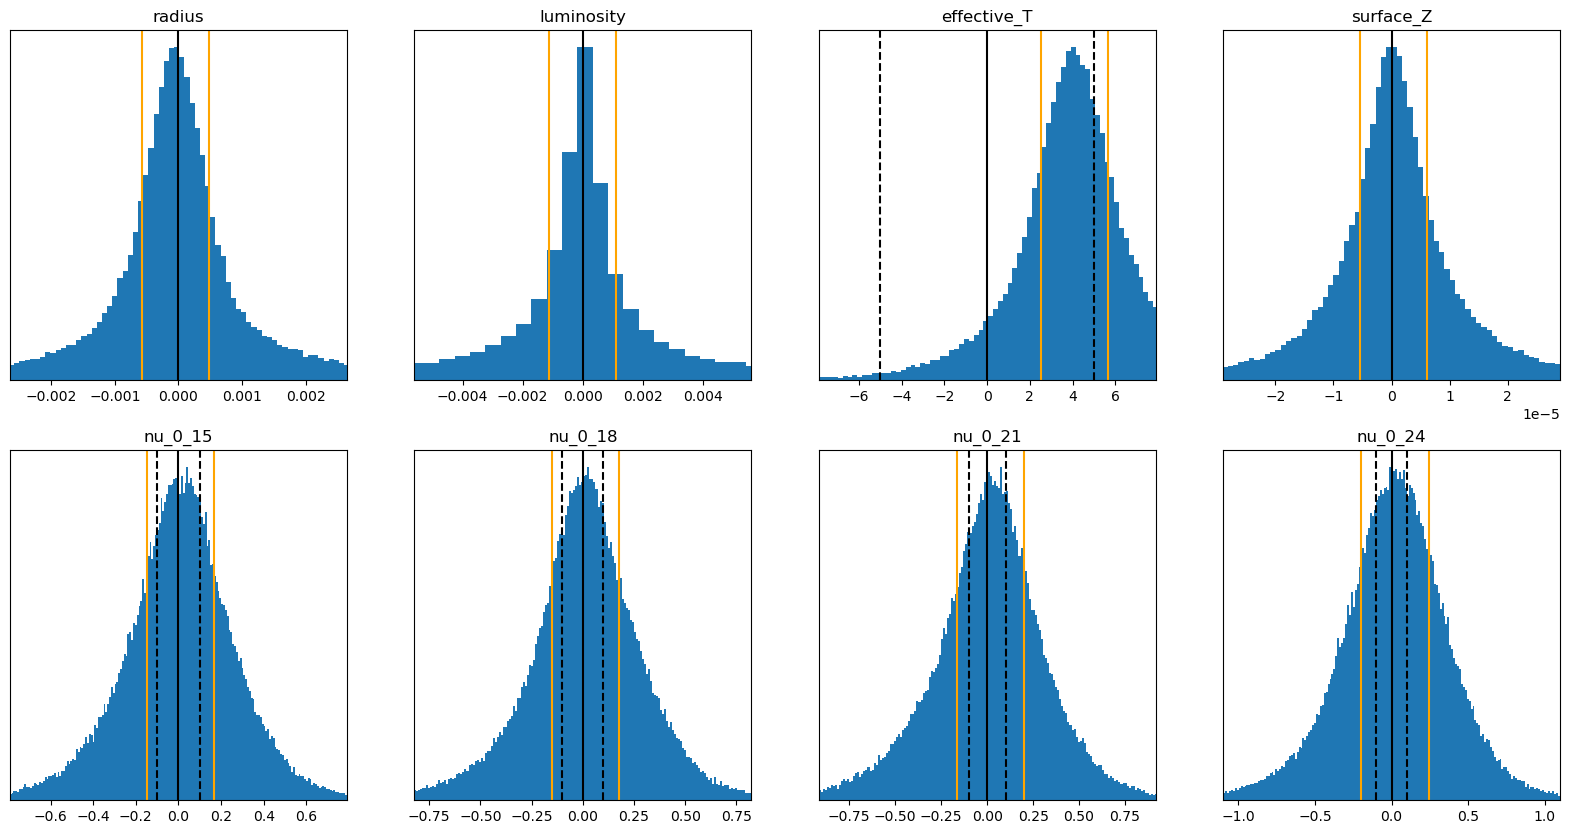

In [12]:
pitchfork_eval(pitchfork, df_test)

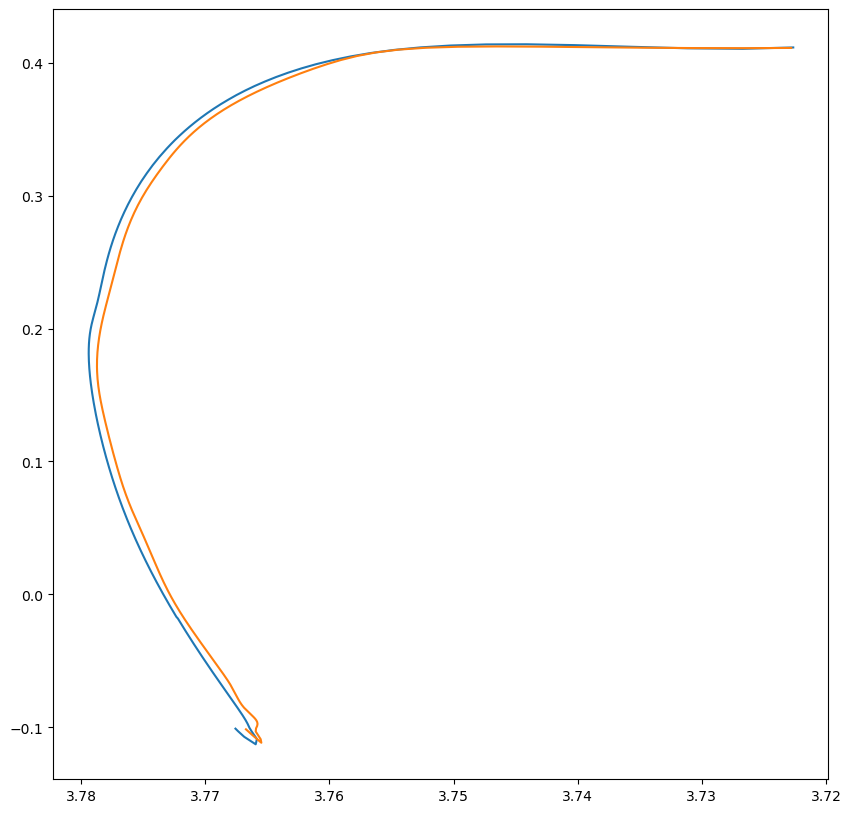

In [34]:
pca_comps = pca.components_
pca_mean = pca.mean_

# extract solar track:
df_mass = df_full[df_full["initial_mass"]==1.0]

df_mass_zinit = df_mass[df_mass["initial_Zinit"] == df_mass.iloc[(df_mass['initial_Zinit']-0.014).abs().argsort()[:1]]['initial_Zinit'].tolist()[0]]
df_mass_zinit = df_mass_zinit.set_index(np.arange(0,len(df_mass_zinit)))

custom_objects = {"InversePCA": InversePCA(pca_comps, pca_mean),"WMSE": WMSE(weights)}


fig, ax = plt.subplots(figsize=(10,10), dpi=100)
pitchfork_name = "stem_2_256_ctine_2_64_atine_12_128_WMSE_32768batch_exp2e4_100kepochs_swish_001lr_00006exp"
pcann_model = tf.keras.models.load_model("/home/oxs235/datastorage/repos_data/ojscutt/pitchfork/models/barbie/" + pitchfork_name + ".h5", custom_objects=custom_objects)

preds = pcann_model(np.array(df_mass_zinit[inputs]))

classical_preds = pd.DataFrame(np.array(preds[0]), columns=[classical_outputs])

for classical_output in ['radius', 'luminosity']:
    classical_preds["log_"+classical_output] = (classical_preds["log_"+classical_output+"_std"]*df_full["log_"+classical_output].std())+df_full["log_"+classical_output].mean()
    classical_preds[classical_output] = 10**classical_preds["log_" + classical_output]



plt.plot(df_mass_zinit["log_effective_T"], df_mass_zinit["log_luminosity"])

plt.plot(np.log10(calc_Teff(classical_preds["luminosity"],classical_preds["radius"])), np.log10(classical_preds["luminosity"]))


plt.gca().invert_xaxis()

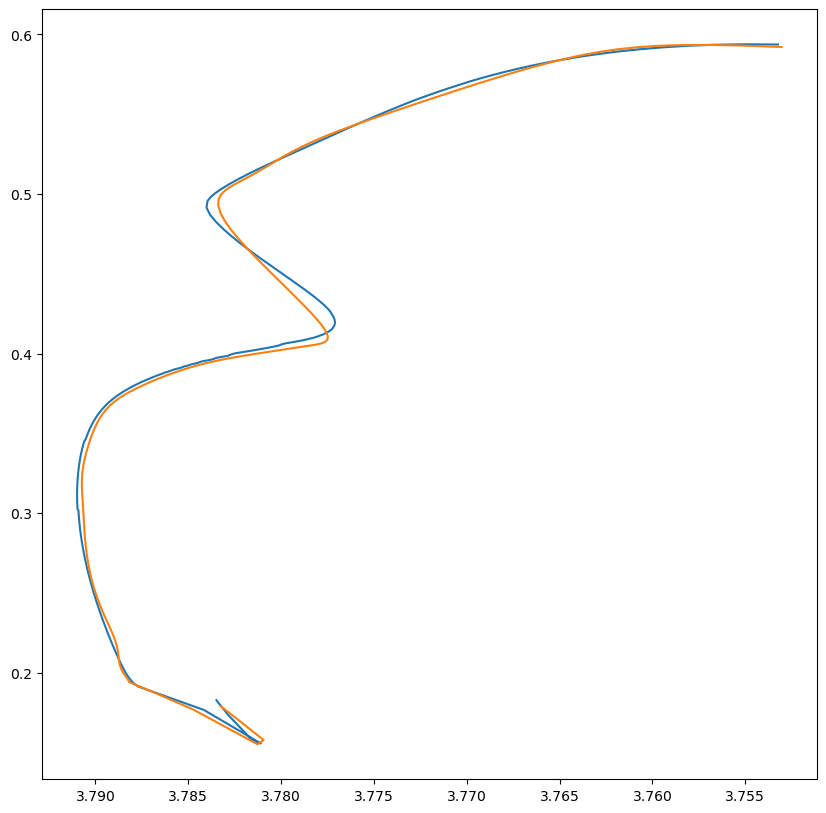

In [145]:
track_point = df_full.sample(1)
df_track = df_full.copy()
df_track = df_full[df_full['initial_mass'] == track_point['initial_mass'].values[0]]
df_track = df_track[df_track['initial_Zinit'] == track_point['initial_Zinit'].values[0]]
df_track = df_track[df_track['initial_Yinit'] == track_point['initial_Yinit'].values[0]]
df_track = df_track[df_track['initial_MLT'] == track_point['initial_MLT'].values[0]]

custom_objects = {"InversePCA": InversePCA(pca_comps, pca_mean),"WMSE": WMSE(weights)}


fig, ax = plt.subplots(figsize=(10,10), dpi=100)
pitchfork_name = "stem_2_256_ctine_2_64_atine_12_128_WMSE_32768batch_exp2e4_100kepochs_swish_001lr_00006exp"
pcann_model = tf.keras.models.load_model("/home/oxs235/datastorage/repos_data/ojscutt/pitchfork/models/barbie/" + pitchfork_name + ".h5", custom_objects=custom_objects)

preds = pcann_model(np.array(df_track[inputs]))

classical_preds = pd.DataFrame(np.array(preds[0]), columns=[classical_outputs])

for classical_output in ['radius', 'luminosity']:
    classical_preds["log_"+classical_output] = (classical_preds["log_"+classical_output+"_std"]*df_full["log_"+classical_output].std())+df_full["log_"+classical_output].mean()
    classical_preds[classical_output] = 10**classical_preds["log_" + classical_output]



#plt.plot(df_track["log_effective_T"], df_track["log_luminosity"])

plt.plot(np.log10(calc_Teff(df_track["luminosity"],df_track["radius"])), df_track["log_luminosity"])

plt.plot(np.log10(calc_Teff(classical_preds["luminosity"],classical_preds["radius"])), np.log10(classical_preds["luminosity"]))


plt.gca().invert_xaxis()